In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [159]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

In [160]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn import tree
from sklearn.decomposition import PCA
from sqlalchemy import create_engine
import joblib


In [161]:
df=pd.read_csv('healthcare_dataset.csv')
df.head(20)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
5,EMILY JOHNSOn,36,Male,A+,Asthma,2023-12-20,Taylor Newton,Nunez-Humphrey,UnitedHealthcare,48145.110951,389,Urgent,2023-12-24,Ibuprofen,Normal
6,edwArD EDWaRDs,21,Female,AB-,Diabetes,2020-11-03,Kelly Olson,Group Middleton,Medicare,19580.872345,389,Emergency,2020-11-15,Paracetamol,Inconclusive
7,CHrisTInA MARtinez,20,Female,A+,Cancer,2021-12-28,Suzanne Thomas,"Powell Robinson and Valdez,",Cigna,45820.462722,277,Emergency,2022-01-07,Paracetamol,Inconclusive
8,JASmINe aGuIlaR,82,Male,AB+,Asthma,2020-07-01,Daniel Ferguson,Sons Rich and,Cigna,50119.222792,316,Elective,2020-07-14,Aspirin,Abnormal
9,ChRISTopher BerG,58,Female,AB-,Cancer,2021-05-23,Heather Day,Padilla-Walker,UnitedHealthcare,19784.631062,249,Elective,2021-06-22,Paracetamol,Inconclusive


In [162]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [163]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 6.4 MB


In [164]:
df['Date of Admission']=pd.to_datetime(df['Date of Admission'])
df['Discharge Date']=pd.to_datetime(df['Discharge Date'])
df['Room Number']=df['Room Number'].astype('str')

In [165]:
numerical_columns=df.select_dtypes(include=['number']).columns
print(numerical_columns)

Index(['Age', 'Billing Amount'], dtype='str')


In [166]:
df['Room Number'].unique

<bound method Series.unique of 0        328
1        265
2        205
3        450
4        458
        ... 
55495    417
55496    316
55497    347
55498    321
55499    448
Name: Room Number, Length: 55500, dtype: str>

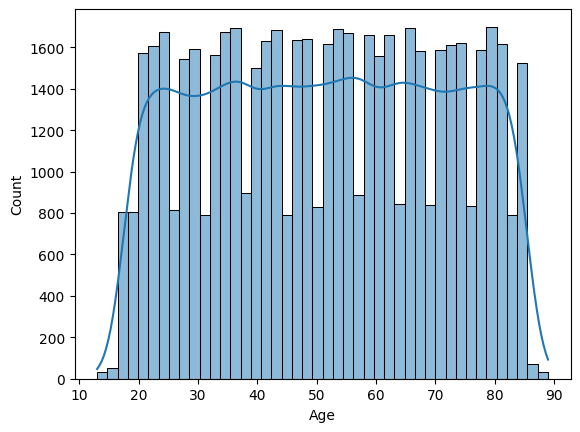

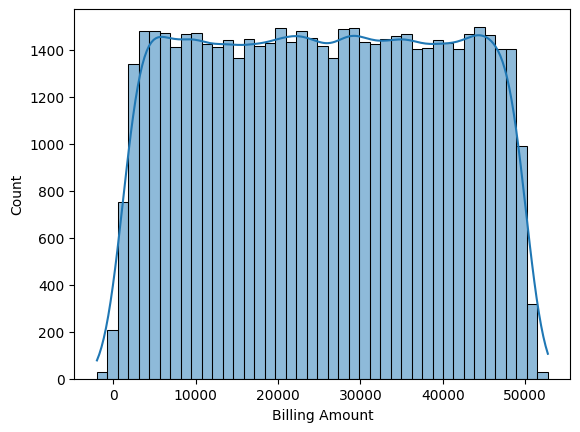

In [167]:
#to see the distribution 
for i in numerical_columns:
    sns.histplot(df[i],kde=True)
    plt.show()

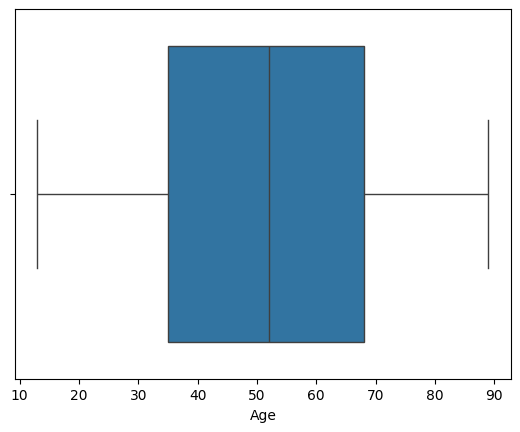

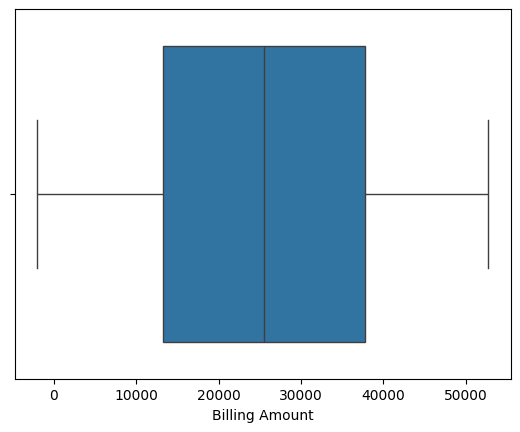

In [168]:
#check for outliers
for i in numerical_columns:
    sns.boxplot(x=df[i])
    plt.show()

In [169]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='str')

In [170]:
categorical_columns=df.select_dtypes(include=['object']).columns
print(categorical_columns)

Index(['Name', 'Gender', 'Blood Type', 'Medical Condition', 'Doctor',
       'Hospital', 'Insurance Provider', 'Room Number', 'Admission Type',
       'Medication', 'Test Results'],
      dtype='str')


C:\Users\PC\AppData\Local\Temp\ipykernel_10724\3454359425.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns=df.select_dtypes(include=['object']).columns


In [171]:
#encode the categorical columns by using label encoing

encoder=LabelEncoder()
for i in categorical_columns:
    df[i]=encoder.fit_transform(df[i])
    
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,3068,30,1,5,2,2024-01-31,26612,29933,1,18856.281306,227,2,2024-02-02,3,2
1,15211,62,1,0,5,2019-08-20,33648,16012,3,33643.327287,164,1,2019-08-26,1,1
2,6476,76,0,1,5,2022-09-22,37828,5473,0,27955.096079,104,1,2022-10-07,0,2
3,26935,28,0,6,3,2020-11-18,22511,12317,3,37909.782410,349,0,2020-12-18,1,0
4,26241,43,0,2,2,2022-09-19,21259,33598,0,14238.317814,357,2,2022-10-09,4,0


In [172]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                55500 non-null  int64         
 1   Age                 55500 non-null  int64         
 2   Gender              55500 non-null  int64         
 3   Blood Type          55500 non-null  int64         
 4   Medical Condition   55500 non-null  int64         
 5   Date of Admission   55500 non-null  datetime64[us]
 6   Doctor              55500 non-null  int64         
 7   Hospital            55500 non-null  int64         
 8   Insurance Provider  55500 non-null  int64         
 9   Billing Amount      55500 non-null  float64       
 10  Room Number         55500 non-null  int64         
 11  Admission Type      55500 non-null  int64         
 12  Discharge Date      55500 non-null  datetime64[us]
 13  Medication          55500 non-null  int64         
 14  T

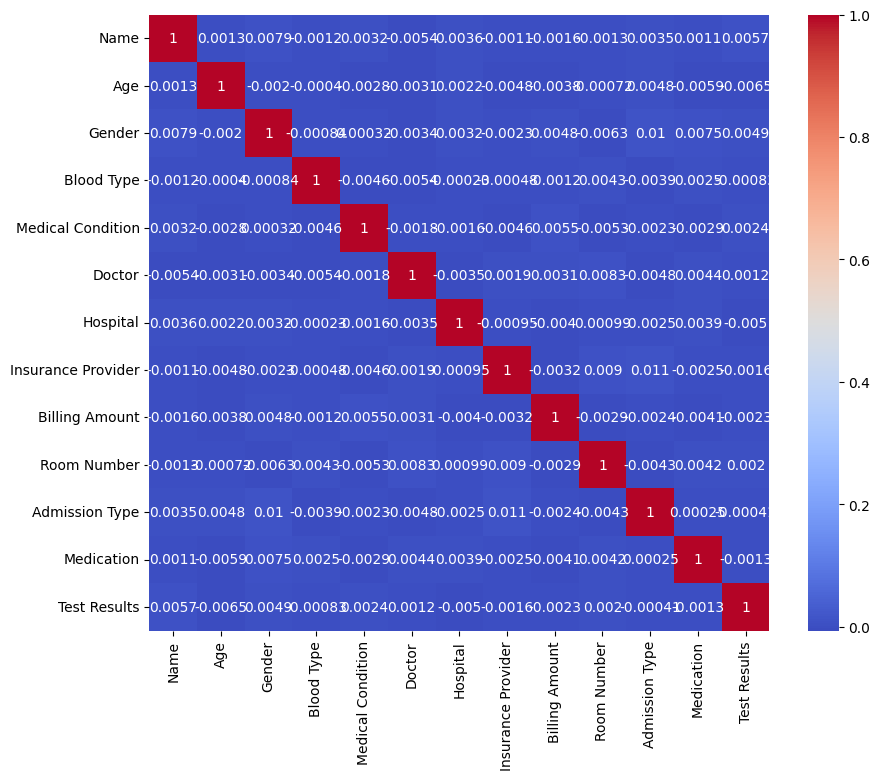

In [173]:
# to see the correlation among variables
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

In [174]:
df.describe()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
count,55500.000000,55500.000000,55500.000000,55500.000000,55500.000000,55500,55500.000000,55500.000000,55500.000000,55500.000000,55500.000000,55500.000000,55500,55500.000000,55500.000000
mean,25000.456847,51.539459,0.500432,3.492595,2.498847,2021-11-01 01:02:22.443243,20194.877604,19656.653892,2.009351,25539.316097,200.134829,0.998577,2021-11-16 13:15:20.821621,1.998054,0.998018
min,0.000000,13.000000,0.000000,0.000000,0.000000,2019-05-08 00:00:00,0.000000,0.000000,0.000000,-2008.492140,0.000000,0.000000,2019-05-09 00:00:00,0.000000,0.000000
25%,12508.750000,35.000000,0.000000,1.000000,1.000000,2020-07-28 00:00:00,10151.750000,10608.000000,1.000000,13241.224652,101.000000,0.000000,2020-08-12 00:00:00,1.000000,0.000000
50%,25010.500000,52.000000,1.000000,3.000000,3.000000,2021-11-01 00:00:00,20050.500000,18950.500000,2.000000,25538.069376,201.000000,1.000000,2021-11-17 00:00:00,2.000000,1.000000
75%,37476.250000,68.000000,1.000000,5.000000,4.000000,2023-02-03 00:00:00,30111.250000,29099.250000,3.000000,37820.508436,300.000000,2.000000,2023-02-18 00:00:00,3.000000,2.000000
max,49991.000000,89.000000,1.000000,7.000000,5.000000,2024-05-07 00:00:00,40340.000000,39875.000000,4.000000,52764.276736,399.000000,2.000000,2024-06-06 00:00:00,4.000000,2.000000
std,14429.751564,19.602454,0.500004,2.289700,1.708336,NaN,11531.448639,11111.199156,1.410144,14211.454431,115.243069,0.819048,NaN,1.413244,0.818089


In [175]:
df.drop_duplicates()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,3068,30,1,5,2,2024-01-31,26612,29933,1,18856.281306,227,2,2024-02-02,3,2
1,15211,62,1,0,5,2019-08-20,33648,16012,3,33643.327287,164,1,2019-08-26,1,1
2,6476,76,0,1,5,2022-09-22,37828,5473,0,27955.096079,104,1,2022-10-07,0,2
3,26935,28,0,6,3,2020-11-18,22511,12317,3,37909.782410,349,0,2020-12-18,1,0
4,26241,43,0,2,2,2022-09-19,21259,33598,0,14238.317814,357,2,2022-10-09,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,32416,42,0,6,1,2020-08-16,20003,15553,1,2650.714952,316,0,2020-09-15,4,0
55496,13686,61,0,3,5,2020-01-23,37149,31722,2,31457.797307,215,0,2020-02-01,0,2
55497,8742,38,0,4,4,2020-07-13,18550,37408,4,27620.764717,246,2,2020-08-10,1,0
55498,9759,43,1,7,0,2019-05-25,22665,14329,3,32451.092358,220,0,2019-05-31,1,0


In [176]:
df['Days_in_hospital']=(df['Discharge Date']-df['Date of Admission']).dt.days
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Days_in_hospital
0,3068,30,1,5,2,2024-01-31,26612,29933,1,18856.281306,227,2,2024-02-02,3,2,2
1,15211,62,1,0,5,2019-08-20,33648,16012,3,33643.327287,164,1,2019-08-26,1,1,6
2,6476,76,0,1,5,2022-09-22,37828,5473,0,27955.096079,104,1,2022-10-07,0,2,15
3,26935,28,0,6,3,2020-11-18,22511,12317,3,37909.782410,349,0,2020-12-18,1,0,30
4,26241,43,0,2,2,2022-09-19,21259,33598,0,14238.317814,357,2,2022-10-09,4,0,20


In [177]:
df.drop(['Discharge Date','Date of Admission'],axis=1,inplace=True)

In [178]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Doctor',
       'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number',
       'Admission Type', 'Medication', 'Test Results', 'Days_in_hospital'],
      dtype='str')

In [179]:
#split the data into training and test data
X=df.drop(columns='Test Results')
y=df['Test Results']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [180]:
y_train

45174    0
10214    2
43199    0
31626    2
9273     1
        ..
44732    1
54343    2
38158    1
860      0
15795    2
Name: Test Results, Length: 44400, dtype: int64

In [181]:
#XGboost classifier 
xg=XGBClassifier()
model=xg.fit(X_train,y_train)


In [182]:
#prediction
y_pred=model.predict(X_test)

In [183]:
#Evaluate the model
print(f'Accuracy :{accuracy_score(y_test,y_pred)}')

print(confusion_matrix(y_test,y_pred))

print(classification_report(y_test,y_pred))

Accuracy :0.3910810810810811
[[1501 1122 1131]
 [1154 1443 1020]
 [1155 1177 1397]]
              precision    recall  f1-score   support

           0       0.39      0.40      0.40      3754
           1       0.39      0.40      0.39      3617
           2       0.39      0.37      0.38      3729

    accuracy                           0.39     11100
   macro avg       0.39      0.39      0.39     11100
weighted avg       0.39      0.39      0.39     11100



In [184]:
X.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Doctor',
       'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number',
       'Admission Type', 'Medication', 'Days_in_hospital'],
      dtype='str')

In [185]:
# Use Decision tree algorithm
model2=tree.DecisionTreeClassifier()
model2.fit(X_train,y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [186]:
y_pred_2=model2.predict(X_test)

In [187]:
#Evaluate the model
print(f'Accuracy :{accuracy_score(y_test,y_pred_2)}')

print(confusion_matrix(y_test,y_pred_2))

print(classification_report(y_test,y_pred_2))

Accuracy :0.4298198198198198
[[1623 1068 1063]
 [1013 1582 1022]
 [1055 1108 1566]]
              precision    recall  f1-score   support

           0       0.44      0.43      0.44      3754
           1       0.42      0.44      0.43      3617
           2       0.43      0.42      0.42      3729

    accuracy                           0.43     11100
   macro avg       0.43      0.43      0.43     11100
weighted avg       0.43      0.43      0.43     11100



In [188]:
## We do some dimension reduction using PCA to find the most impactful features
pca=PCA(n_components=4)
X_pca=pca.fit_transform(X)
x_train,x_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,random_state=42)

print(f'Explained variance ratio :{pca.explained_variance_ratio_}') #this shows the contribution of each feature in prediction in our case 4 features contribute to 99% explanation

Explained variance ratio :[0.31239418 0.30294956 0.19948077 0.18515486]


In [189]:
#To know this  4 features
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(len(pca.components_))],
    index=x_train.columns
)
top_features = loadings.abs().idxmax()
print("Dominant original features for each PC:")
print(top_features.head(4))

Dominant original features for each PC:
PC1              Name
PC2    Billing Amount
PC3            Doctor
PC4          Hospital
dtype: str


In [190]:
X.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Doctor',
       'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number',
       'Admission Type', 'Medication', 'Days_in_hospital'],
      dtype='str')

In [191]:
X.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Doctor',
       'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number',
       'Admission Type', 'Medication', 'Days_in_hospital'],
      dtype='str')

In [192]:
X1=X[['Name','Billing Amount','Doctor','Hospital']]
x1_train,x1_test,y1_train,y1_test=train_test_split(X1,y,test_size=0.2,random_state=42)


In [193]:
model2.fit(x1_train,y_train)
y1_pred=model2.predict(x1_test)

In [194]:
print(accuracy_score(y1_test,y1_pred))

0.43342342342342344


In [195]:
## Saving the model

joblib.dump(model2,'my_classifier.pkl')

['my_classifier.pkl']

In [196]:
joblib.dump(encoder,'my_encoder.pkl')

['my_encoder.pkl']